# San Jose 311 Service Requests — Exploratory Data Analysis

Loads directly from the SQLite star schema (`data/processed/sj311.db`) rather than the raw CSV — this notebook explores the *analysis-ready* data, and any transform decision belongs in `src/clean.py`, not repeated here.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

conn = sqlite3.connect("../data/processed/sj311.db")

requests = pd.read_sql(
    """
    SELECT
        f.incident_id, f.resolution_hours, f.resolution_hours_capped,
        f.is_zero_duration, f.is_weekend_submission, f.district_id,
        ds.status_name, dst.service_type_name, dep.department_name,
        dc.channel_name, dt.year, dt.quarter, dt.month, dt.month_name
    FROM fact_service_requests f
    JOIN dim_status ds ON f.status_id = ds.status_id
    JOIN dim_service_type dst ON f.service_type_id = dst.service_type_id
    JOIN dim_department dep ON f.department_id = dep.department_id
    JOIN dim_channel dc ON f.channel_id = dc.channel_id
    JOIN dim_date dt ON f.date_created_id = dt.date_id
    """,
    conn,
)
print(requests.shape)
requests.head()

(1123066, 14)


,incident_id,resolution_hours,resolution_hours_capped,is_zero_duration,is_weekend_submission,district_id,status_name,service_type_name,department_name,channel_name,year,quarter,month,month_name
0,642399,2427.919167,2427.919167,0,0,10,Closed,Other Issues,Fire,Self-Service Digital,2021,1,1,January
1,642400,2427.314167,2427.314167,0,0,2,Closed,Abandoned Vehicle,DOT,Self-Service Digital,2021,1,1,January
2,642401,70.677500,70.677500,0,0,NaN,Closed,Graffiti,Parks and Recreation,Self-Service Digital,2021,1,1,January
3,642402,2420.014444,2420.014444,0,0,6,Closed,Abandoned Vehicle,DOT,Self-Service Digital,2021,1,1,January
4,642403,2419.501389,2419.501389,0,0,4,Closed,Abandoned Vehicle,DOT,Self-Service Digital,2021,1,1,January


## 1. Resolution time is heavily right-skewed

This is the chart that justifies using median/p90 instead of mean everywhere else in the project (SQL queries, regression target). Plotting on a log x-axis is what makes the shape visible at all — on a linear axis, the multi-week outliers compress everything under ~200 hours into an unreadable spike at the origin.

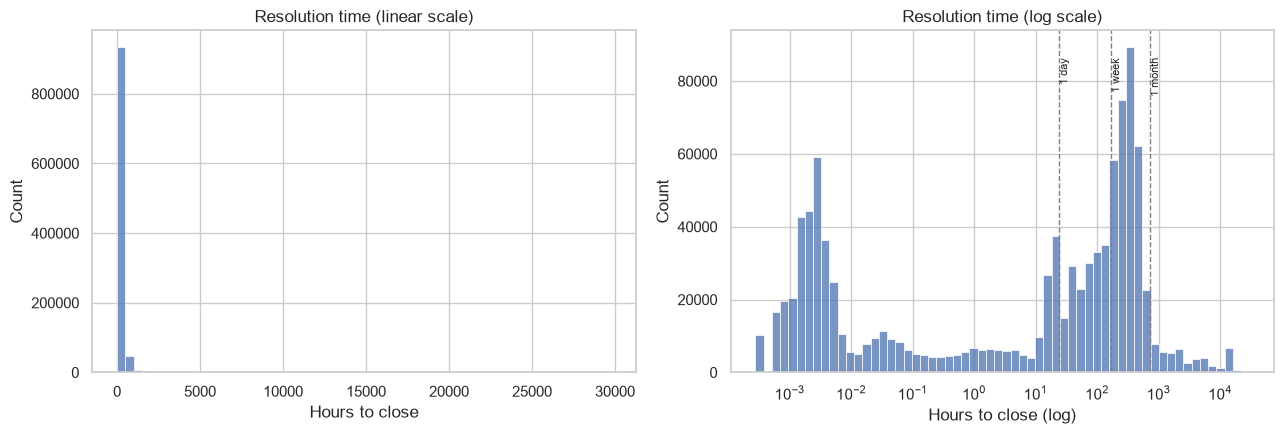

count    1.019309e+06
mean     3.213889e+02
std      1.388035e+03
min      2.777778e-04
50%      2.737083e+01
75%      2.574608e+02
90%      4.507758e+02
99%      6.671161e+03
max      2.976120e+04
Name: resolution_hours, dtype: float64


In [2]:
closed = requests[(requests["status_name"] == "Closed") & (~requests["is_zero_duration"])].copy()
positive_hours = closed.loc[closed["resolution_hours"] > 0, "resolution_hours"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(positive_hours, bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Resolution time (linear scale)")
axes[0].set_xlabel("Hours to close")

sns.histplot(positive_hours, bins=60, log_scale=True, ax=axes[1], color="#4C72B0")
axes[1].set_title("Resolution time (log scale)")
axes[1].set_xlabel("Hours to close (log)")
for h, label in [(24, "1 day"), (168, "1 week"), (720, "1 month")]:
    axes[1].axvline(h, color="grey", linestyle="--", linewidth=1)
    axes[1].text(h, axes[1].get_ylim()[1] * 0.92, label, rotation=90, fontsize=8, va="top")

plt.tight_layout()
plt.savefig("../docs/fig_resolution_time_distribution.png", dpi=150)
plt.show()

print(positive_hours.describe(percentiles=[0.5, 0.75, 0.9, 0.99]))

## 2. Seasonal / trend pattern

Quarterly volume and median resolution time, citywide. Looking for two things: whether request volume has a seasonal rhythm (e.g. summer spikes in outdoor-service complaints), and whether resolution time is trending up, down, or flat independent of volume — a rising trend line with flat volume would point at a process problem rather than a capacity problem.

/var/folders/w2/8zvn_q_s6236zcltht_kpdnm0000gn/T/ipykernel_9352/718127535.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(quarterly["period"], rotation=45, ha="right")


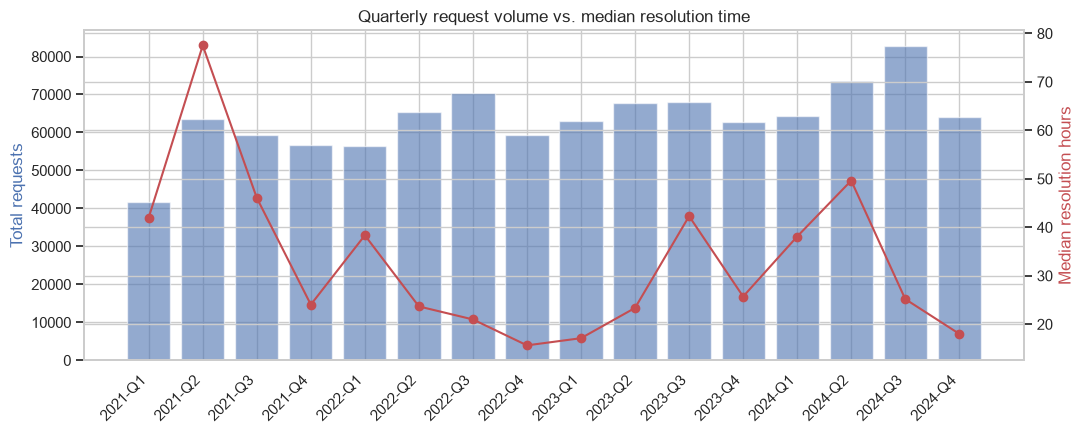

In [3]:
quarterly = (
    closed.assign(period=closed["year"].astype(str) + "-Q" + closed["quarter"].astype(str))
    .groupby(["year", "quarter", "period"])
    .agg(total_requests=("incident_id", "count"), median_hours=("resolution_hours", "median"))
    .reset_index()
    .sort_values(["year", "quarter"])
)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()

ax1.bar(quarterly["period"], quarterly["total_requests"], color="#4C72B0", alpha=0.6, label="Total requests")
ax2.plot(quarterly["period"], quarterly["median_hours"], color="#C44E52", marker="o", label="Median resolution hours")

ax1.set_ylabel("Total requests", color="#4C72B0")
ax2.set_ylabel("Median resolution hours", color="#C44E52")
ax1.set_xticklabels(quarterly["period"], rotation=45, ha="right")
plt.title("Quarterly request volume vs. median resolution time")
fig.tight_layout()
plt.savefig("../docs/fig_quarterly_trend.png", dpi=150)
plt.show()

## 3. District × service type heatmap

Median resolution time for the highest-volume service types, broken out by district. This is the visual counterpart of `sql/analysis/03_slowest_service_types_per_district.sql` — a table of ranks tells you *that* something is worse in a district, a heatmap makes it obvious *where* at a glance, which is the point of putting it in front of a non-technical audience later on the Tableau dashboard.

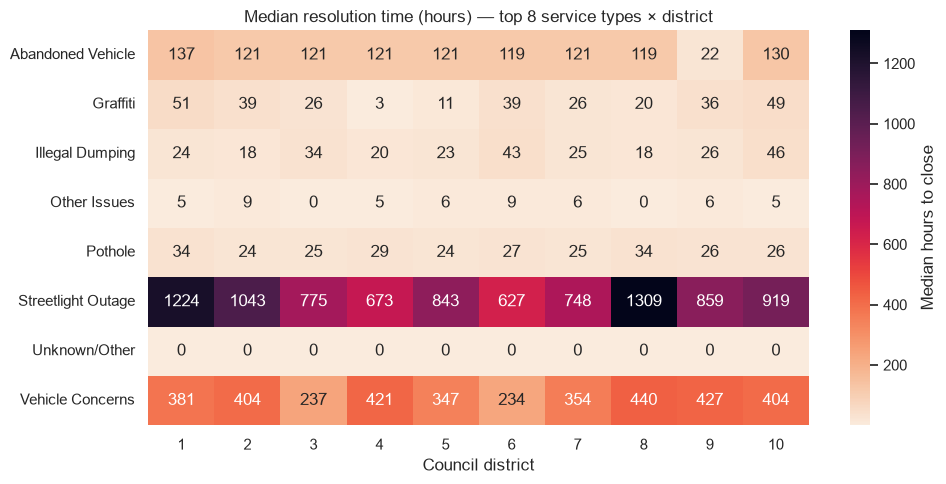

In [4]:
has_district = closed.dropna(subset=["district_id"]).copy()
has_district["district_id"] = has_district["district_id"].astype(int)

top_types = has_district["service_type_name"].value_counts().head(8).index
subset = has_district[has_district["service_type_name"].isin(top_types)]

pivot = subset.pivot_table(
    index="service_type_name", columns="district_id", values="resolution_hours", aggfunc="median"
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="rocket_r", cbar_kws={"label": "Median hours to close"})
plt.title("Median resolution time (hours) — top 8 service types × district")
plt.xlabel("Council district")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../docs/fig_district_service_type_heatmap.png", dpi=150)
plt.show()

## 4. Channel comparison (sets up the Phase 6 hypothesis test)

`sql/analysis/06_channel_comparison.sql` already showed a large median gap between Self-Service Digital and Staff-Assisted requests. A boxplot on a log axis shows *why* a t-test would be the wrong tool here: the two distributions aren't just shifted, they have very different shapes and spread — exactly the condition where a non-parametric test (Mann-Whitney U, next phase) is the defensible choice over comparing means.

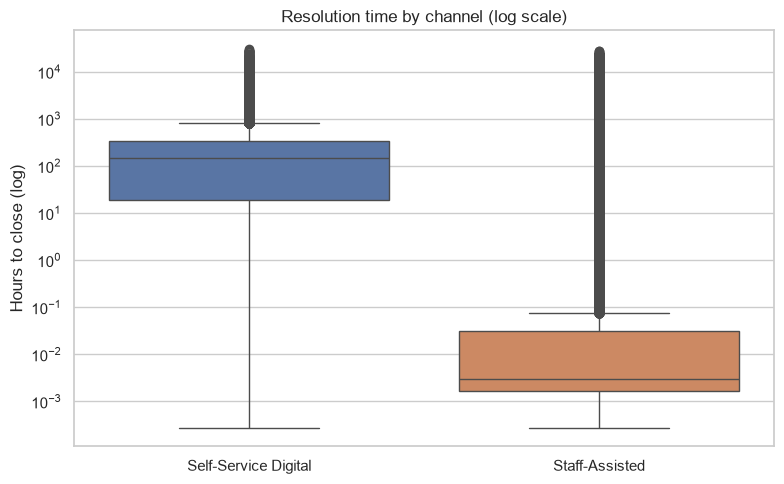

channel_name
Self-Service Digital    145.168611
Staff-Assisted            0.003056
Name: resolution_hours, dtype: float64

In [5]:
channel_data = closed[(closed["channel_name"] != "Unknown") & (closed["resolution_hours"] > 0)]

plt.figure(figsize=(8, 5))
sns.boxplot(data=channel_data, x="channel_name", y="resolution_hours", hue="channel_name", legend=False)
plt.yscale("log")
plt.title("Resolution time by channel (log scale)")
plt.xlabel("")
plt.ylabel("Hours to close (log)")
plt.tight_layout()
plt.savefig("../docs/fig_channel_comparison.png", dpi=150)
plt.show()

channel_data.groupby("channel_name")["resolution_hours"].median()